# pyGIMLi(empymod)

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import pygimli
import empymod

rng = np.random.default_rng(seed=0)

## Create survey, model, and data

In [3]:
# Survey: Offsets and Frequencies
rec_offsets = np.arange(0,300, 7.5)
frequencies = [10, 1000, 10000]

#Resistivity definition
base_res = 35 #Ohmm
anom_res = 20 #Ohmm

# Model depths and resistivities
depth = [0, 110, 190]
mtrue = [2e14, base_res, anom_res, base_res]
m0 = [2e14, base_res, base_res, base_res]

# Collect input parameters
inp = {
    'src': [-200, -180, 0, 0, 0, 0],
    'rec': [rec_offsets*0, rec_offsets*0, rec_offsets, 0, 90],
    'depth': depth,
    'freqtime': frequencies,
    'verb': 1,
}

# Create observed data and background == start model data
dobs = empymod.bipole(res=mtrue, **inp)
d0 = empymod.bipole(res=m0, **inp)

### Add noise to `dobs`
=> The following cell should go into `empymod`, or use `emg3d`, where it is already implemented

In [4]:
noise_floor = 1e-15
relative_error = 0.05
mean_noise = 0.0

# Exclude data below half the noise_floor
cut_data = abs(dobs) < (noise_floor / 2)
dobs[cut_data] = np.nan + 1j*np.nan
d0[cut_data] = np.nan + 1j*np.nan

# Add random white noise to dobs
std_dev = np.sqrt(noise_floor**2 + np.abs(relative_error*dobs)**2)
noise = std_dev * ((1+1j)*mean_noise + np.exp(1j * rng.uniform(0, 2*np.pi, dobs.shape)))
dobs += noise

In [5]:
mean_noise = np.mean(np.abs(noise))
print(mean_noise)

1.0823327438189926e-07


In [6]:
print(noise[0,0])

(-7.273805427116559e-06-8.458432416440189e-06j)


## QC model and data

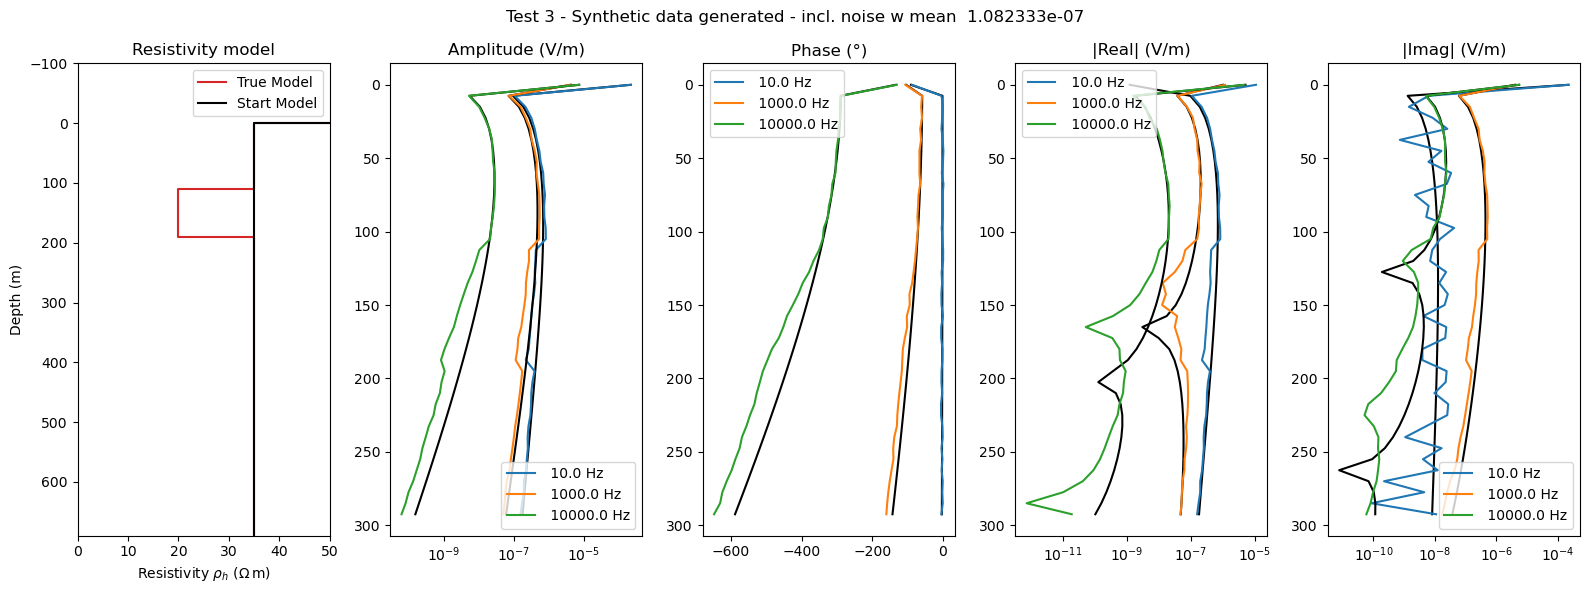

In [5]:
# Plot it
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(16, 6), tight_layout=True)
axes = [ax1, ax2, ax3, ax4, ax5]

p_mtrue = np.repeat(mtrue, 2)
p_m0 = np.repeat(m0, 2)
p_depth = np.r_[-100, np.repeat(depth, 2), 3000]

# Plot Resistivities
ax1.set_title('Resistivity model')
ax1.plot(p_mtrue, p_depth, 'C3', label="True Model")
ax1.plot(p_m0, p_depth, 'k', label="Start Model")
#ax1.set_xscale('log')
ax1.set_xlim([0, 50])
ax1.set_ylim([depth[-1]+500, depth[0]-100])
ax1.set_ylabel('Depth (m)')
ax1.set_xlabel(r'Resistivity $\rho_h\ (\Omega\,\rm{m})$')
ax1.legend()

#Plot measured data
labels = ['Amplitude (V/m)', 'Phase (°)', '|Real| (V/m)', '|Imag| (V/m)']
data_obs = [dobs.amp(), dobs.pha(deg=True), abs(dobs.real), abs(dobs.imag)]
data0 = [d0.amp(), d0.pha(deg=True), abs(d0.real), abs(d0.imag)]
fig.suptitle("Test 3 - Synthetic data generated - incl. noise w mean "+f"{mean_noise: 3e}")
for j in np.arange(len(labels)):
    ax = axes[j+1]
    ax.set_title(labels[j])
    for i, f in enumerate(frequencies):
        ax.plot(data0[j][i,:], rec_offsets, 'k')
        ax.plot(data_obs[j][i,:], rec_offsets, label=f"{f: 2.1f} Hz")  
    ax.invert_yaxis()
    ax.set_xscale('log')
    ax.legend()

ax3.set_xscale('linear')

## Forward Kernel and modified Inversion class
=> The following cell should go into `empymod.inv.pygimli`

In [ ]:
class Kernel(pygimli.Modelling):
    
    def __init__(self, input_map, routine=empymod.bipole):
        """Initialize the model."""
        super().__init__()

        # Store inputs
        self.input_map = input_map
        self.routine = routine
        
    def response(self, x):
        """Forward response."""    

        # Compute responses
        em = self.routine(**self.input_map(x))
        
        # Ravel output, taking care of complex values
        em = np.r_[em.ravel().real, em.ravel().imag if np.iscomplexobj(em) else []]

        # Return required data
        return em if not hasattr(self, 'indices') else em[self.indices]
    
    def createStartModel(self, dataVals=None):
        """Overwrite default method with an Error.""" 
        raise NotImplementedError("Start Model must be provided.")


class Inversion(pygimli.Inversion):
    
    def run(self, dataVals, errorVals=None, **kwargs):

        # Store the mesh (pseudo)
        if "startModel" in kwargs:
            n_model = len(np.atleast_1d(kwargs["startModel"]))
        else:
            n_model = len(self.startModel)
        self.fop.mesh1d = pygimli.meshtools.createMesh1D(n_model)
        self.fop.setMesh(self.fop.mesh1d)

        # Error: Same as in original function, but taking care of complex data
        if errorVals is None:  # use absoluteError and/or relativeError instead
            absErr = kwargs.pop("absoluteError", 0)
            relErr = kwargs.pop("relativeError",
                                0.01 if np.allclose(absErr, 0) else 0)
            errorVals = abs(absErr / np.asarray(abs(dataVals))) + relErr

        if isinstance(errorVals, (float, int)):
            errorVals = np.ones_like(dataVals.real) * errorVals
        
        # Ravel data and decompose complex data
        d_size = dataVals.size
        d_shape = dataVals.shape
        is_complex = False
        if np.iscomplexobj(dataVals):
            is_complex = True
            d_size *= 2
        dataVals = np.r_[dataVals.ravel().real, dataVals.ravel().imag if is_complex else []]
        errorVals = np.r_[errorVals.ravel(), errorVals.ravel() if is_complex else []]

        # Limit to finite values
        if np.any(~np.isfinite(dataVals)):
            self.fop.indices = np.isfinite(dataVals)
            dataVals = dataVals[self.fop.indices]
            errorVals = errorVals[self.fop.indices]

        # Run the inversion
        model = super().run(dataVals=dataVals, errorVals=errorVals, **kwargs)

        # Reshape data           
        if hasattr(self.fop, 'indices'):
            out = np.ones(d_size)*np.nan
            out[self.fop.indices] = np.array(self.response)
        else:
            out = np.array(self.response)
        if is_complex:
            out = out[:d_size//2] + 1j*out[d_size//2:]               
        response = empymod.EMArray(np.reshape(out, d_shape))

        # Return mapped parameters and response
        return self.fop.input_map(model), response

## Inversion

In [ ]:
%%time

def input_map(x, inp=inp):
    """Map the inversion parameter to modelling parameters."""
    # Could be res, aniso, depth, a mixture of it, ...
    inp['res'] =  np.r_[2e14, x]
    return inp

fop = Kernel(input_map, empymod.bipole)
inv = Inversion(fop=fop)

# Not Sure Yet How To Use These
#inv.dataTrans = pygimli.trans.TransSymLog(1e-20)
#inv.transModel = pygimli.trans.TransLog(0.1) # > 1 Ohmm

out, response = inv.run(
    dataVals=dobs,
    absoluteError=std_dev,
    #relativeError=0.01,
    startModel=m0[1:],
    verbose=True
)

inv.post_step
# Get inversion result from parameter dict
# Could be res, aniso, depth, ...
minv = out['res']

09/06/26 - 15:57:18 - pyGIMLi - INFO - Starting inversion.


fop: <__main__.Kernel object at 0x000001EBAA35FEC0>
Data transformation: Identity transform
Model transformation: Logarithmic transform
min/max (data): -2.3e-04/1.1e-05
min/max (error): 4.76%/5.26%
min/max (start model): 35/35
--------------------------------------------------------------------------------
inv.iter 0 ... chi² = 118255.15
--------------------------------------------------------------------------------
inv.iter 1 ... chi² = 14290.30 (dPhi = 87.03%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² = 2251.49 (dPhi = 85.20%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² = 9762.46 (dPhi = -673.57%) lam: 20.0
################################################################################
#               Abort criterion reached: dPhi = -673.57 (< 2.0%)               #
################################################################################
CPU

## Plot result

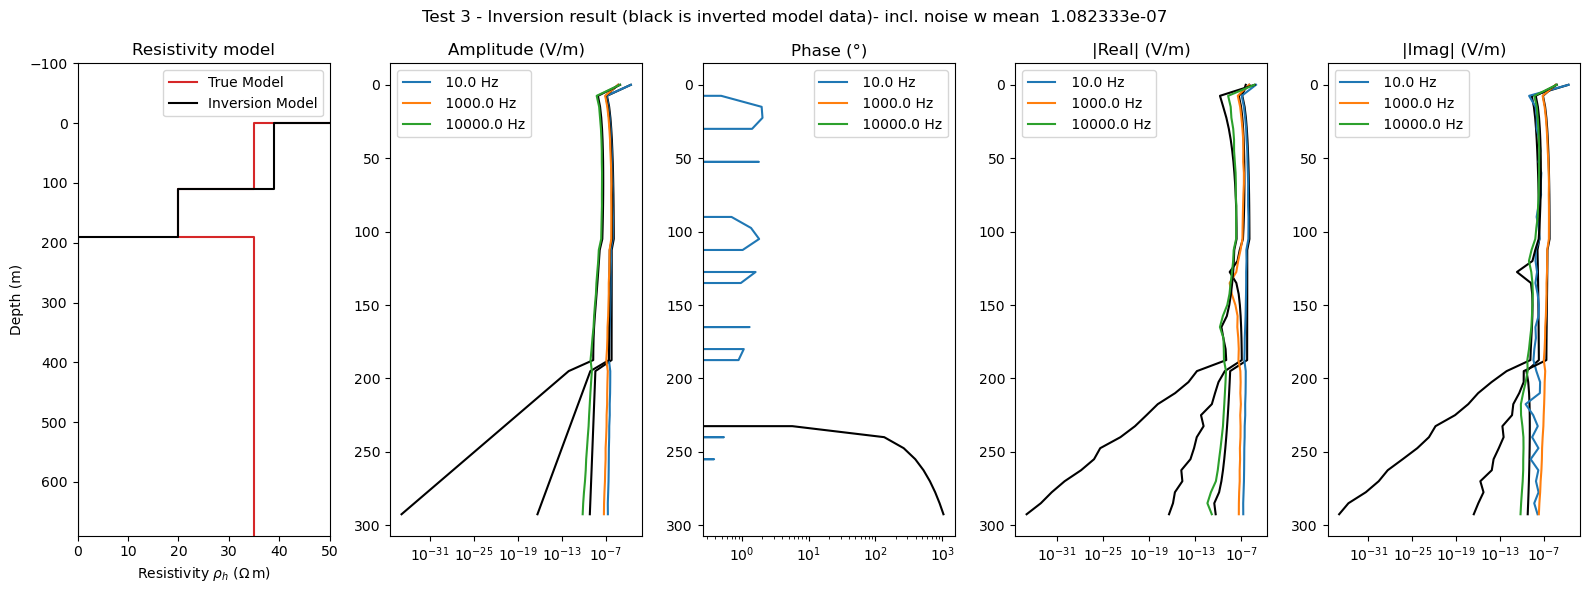

In [16]:
# Plot it
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(16, 6), tight_layout=True)
axes = [ax1, ax2, ax3, ax4, ax5]

p_mtrue = np.repeat(mtrue, 2)
p_m0 = np.repeat(m0, 2)
p_depth = np.r_[-100, np.repeat(depth, 2), 3000]
p_minv = np.repeat(minv, 2)

# Plot Resistivities
ax1.set_title('Resistivity model')
ax1.plot(p_mtrue, p_depth, 'C3', label="True Model")
ax1.plot(p_minv, p_depth, 'k', label="Inversion Model")
#ax1.set_xscale('log')
ax1.set_xlim([0, 50])
ax1.set_ylim([depth[-1]+500, depth[0]-100])
ax1.set_ylabel('Depth (m)')
ax1.set_xlabel(r'Resistivity $\rho_h\ (\Omega\,\rm{m})$')
ax1.legend()

#Plot measured data
labels = ['Amplitude (V/m)', 'Phase (°)', '|Real| (V/m)', '|Imag| (V/m)']
data_obs = [dobs.amp(), dobs.pha(deg=True), abs(dobs.real), abs(dobs.imag)]
data_inv = [response.amp(), response.pha(deg=True), abs(response.real), abs(response.imag)]
fig.suptitle("Test 3 - Inversion result (black is inverted model data)- incl. noise w mean "+f"{mean_noise: 3e}")
for j in np.arange(len(labels)):
    ax = axes[j+1]
    ax.set_title(labels[j])
    for i, f in enumerate(frequencies):
        ax.plot(data_inv[j][i,:], rec_offsets, 'k')
        ax.plot(data_obs[j][i,:], rec_offsets, label=f"{f: 2.1f} Hz")
    ax.invert_yaxis()
    ax.set_xscale('log')
    ax.legend()

In [8]:
empymod.Report(['pyGIMLi', 'pgcore'])

--------------------------------------------------------------------------------
  Date: Mon Jun 01 11:50:33 2026 UTC

                OS : Windows (10 10.0.26100 SP0 Multiprocessor Free)
            CPU(s) : 14
           Machine : AMD64
      Architecture : 64bit
               RAM : 31.4 GiB
       Environment : Jupyter

  Python 3.11.15 | packaged by conda-forge | (main, Mar  5 2026, 16:36:00)
  [MSC v.1944 64 bit (AMD64)]

           pyGIMLi : 1.5.5
            pgcore : 1.5.0
             numpy : 1.26.4
             scipy : 1.14.1
             numba : 0.65.1
           empymod : 2.5.4
            libdlf : 0.3.0
           IPython : 9.10.0
        matplotlib : 3.10.9
--------------------------------------------------------------------------------